# Churn Prediction

*__Churn Prediction__*

```identifying customers who are likely to cancel their contracts soon.```

* If the company can do that, it can handle users before churn
* The target variable that we want to predict is categorical and has only two possible outcomes:
churn or not churn (Binary Classification).

* We will use data from https://www.kaggle.com/blastchar/telco-customer-churn.

*  Dataset Description:
    * __Services of the customers__: phone; multiple lines; internet; tech support and extra services such as online security, backup, device protection, and TV streaming
    * __Account information__: how long they have been clients, type of contract, type of
payment method
    * __Charges__: how much the client was charged in the past month and in total
    * __Demographic information__: gender, age, and whether they have dependents or a partner
    * __Churn__: yes/no, whether the customer left the company within the past month

# Initial Data Preparation

In [1]:
# blastchar_telco_customer_churn_path

In [2]:
# ! pip install kagglehub

# import kagglehub
# blastchar_telco_customer_churn_path = kagglehub.dataset_download('blastchar/telco-customer-churn')
# print('Data source import complete.')

In [3]:
import pandas as pd
import numpy as np

import seaborn as sns
from matplotlib import pyplot as plt

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import make_column_transformer


In [4]:
df = pd.read_csv(r"C:\Users\joseph\.cache\kagglehub\datasets\blastchar\telco-customer-churn\versions\1\WA_Fn-UseC_-Telco-Customer-Churn.csv")
df .head().T

,0,1,2,3,4
customerID,7590-VHVEG,5575-GNVDE,3668-QPYBK,7795-CFOCW,9237-HQITU
gender,Female,Male,Male,Male,Female
SeniorCitizen,0,0,0,0,0
Partner,Yes,No,No,No,No
Dependents,No,No,No,No,No
tenure,1,34,2,45,2
PhoneService,No,Yes,Yes,No,Yes
MultipleLines,No phone service,No,No,No phone service,No
InternetService,DSL,DSL,DSL,DSL,Fiber optic
OnlineSecurity,No,Yes,Yes,Yes,No


In [5]:
 df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
df.describe(include='object').T

,count,unique,top,freq
customerID,7043,7043,7590-VHVEG,1
gender,7043,2,Male,3555
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095


* > ### Customer ID: It is not an important feature, we will drop it

In [8]:
df.drop ('customerID', axis=1, inplace=True)
df.head().T

,0,1,2,3,4
gender,Female,Male,Male,Male,Female
SeniorCitizen,0,0,0,0,0
Partner,Yes,No,No,No,No
Dependents,No,No,No,No,No
tenure,1,34,2,45,2
PhoneService,No,Yes,Yes,No,Yes
MultipleLines,No phone service,No,No,No phone service,No
InternetService,DSL,DSL,DSL,DSL,Fiber optic
OnlineSecurity,No,Yes,Yes,Yes,No
OnlineBackup,Yes,No,Yes,No,No


* > ### Handle `TotalCharges`:  from description, it has white space in 11 rows, we need to handle it

In [9]:
df.TotalCharges.describe()

count     7043
unique    6531
top       20.2
freq        11
Name: TotalCharges, dtype: object

In [10]:
df[df['TotalCharges']==' ']

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


* > ### Convert the "TotalCharges" column to numeric and Use enforce white spaces to be 'NaN'

In [11]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [12]:
len((df[df['TotalCharges']==' ']))

0

In [13]:
df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

* > ### We have missing values in `totalcharges`, we need to handel it

In [14]:
df.TotalCharges.describe()

count    7032.000000
mean     2283.300441
std      2266.771362
min        18.800000
25%       401.450000
50%      1397.475000
75%      3794.737500
max      8684.800000
Name: TotalCharges, dtype: float64

<Axes: >

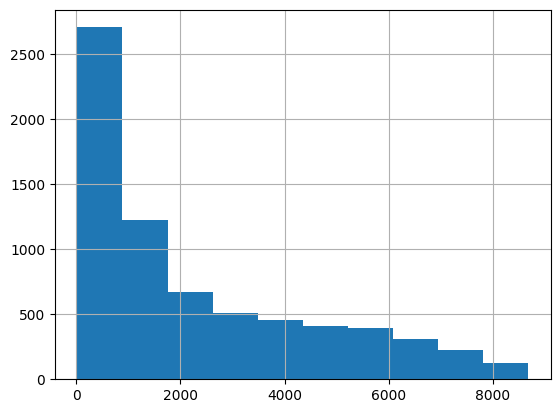

In [15]:
df['TotalCharges'].hist()

* > ### As the distribution of `totalcharges` is `skewed`, we can impute the missing values with its `median`

In [16]:
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [17]:
df.Churn = (df.Churn == 'Yes').astype(int)

In [18]:
df.Churn.value_counts() 

Churn
0    5174
1    1869
Name: count, dtype: int64

C:\Users\joseph\AppData\Local\Temp\ipykernel_8240\1540218597.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x = 'Churn', data = df,palette='Blues_d')


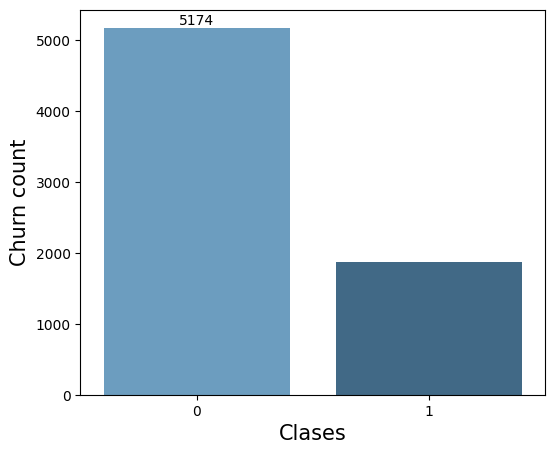

In [19]:
plt.figure(figsize=(6,5))
ax = sns.countplot(x = 'Churn', data = df,palette='Blues_d')
ax.bar_label(ax.containers[0], label_type = 'edge',)
plt.xlabel("Clases", fontsize = 15)
plt.ylabel("Churn count", fontsize = 15)
plt.show()

* > ### We have imbalance in `Churn` column

In [20]:
df['SeniorCitizen'] = df['SeniorCitizen'].astype(object)

# EDA

In [21]:
df.select_dtypes(include='object').columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [29]:
categorical = list (df.select_dtypes(include='object').columns)
categorical

['gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

In [30]:
numerical = list (df.select_dtypes(exclude='object').columns)
numerical

['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']

* > ### Split the Data into categorical and numerical to be easier for Analysis

In [31]:
numerical.remove('Churn')
numerical

['tenure', 'MonthlyCharges', 'TotalCharges']

In [25]:
df[categorical].nunique()

gender              2
SeniorCitizen       2
Partner             2
Dependents          2
PhoneService        2
MultipleLines       3
InternetService     3
OnlineSecurity      3
OnlineBackup        3
DeviceProtection    3
TechSupport         3
StreamingTV         3
StreamingMovies     3
Contract            3
PaperlessBilling    2
PaymentMethod       4
dtype: int64

In [26]:
global_mean = df.Churn.mean()
round(global_mean, 2)

np.float64(0.27)

> * ### We need to check if there is a correlation between the target and categorical columns, so we will make a group by between the `Churn` mean and every categorical column and compare.

C:\Users\joseph\AppData\Local\Temp\ipykernel_8240\1798210915.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\joseph\AppData\Local\Temp\ipykernel_8240\1798210915.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\joseph\AppData\Local\Temp\ipykernel_8240\1798210915.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


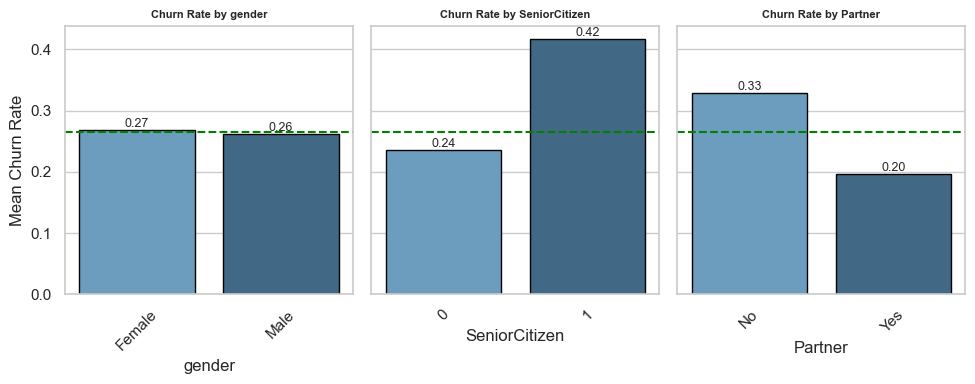

C:\Users\joseph\AppData\Local\Temp\ipykernel_8240\1798210915.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\joseph\AppData\Local\Temp\ipykernel_8240\1798210915.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\joseph\AppData\Local\Temp\ipykernel_8240\1798210915.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


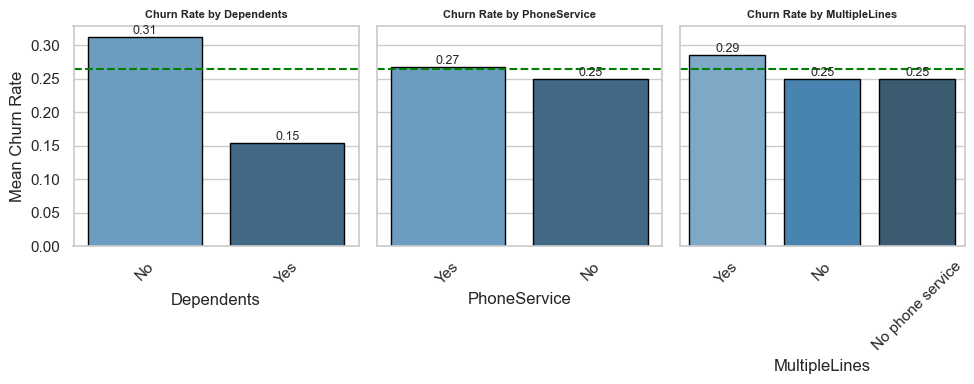

C:\Users\joseph\AppData\Local\Temp\ipykernel_8240\1798210915.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\joseph\AppData\Local\Temp\ipykernel_8240\1798210915.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\joseph\AppData\Local\Temp\ipykernel_8240\1798210915.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


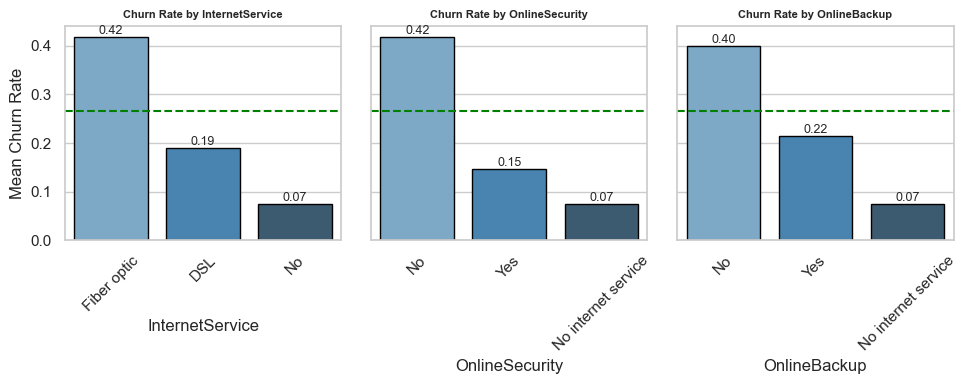

C:\Users\joseph\AppData\Local\Temp\ipykernel_8240\1798210915.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\joseph\AppData\Local\Temp\ipykernel_8240\1798210915.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\joseph\AppData\Local\Temp\ipykernel_8240\1798210915.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


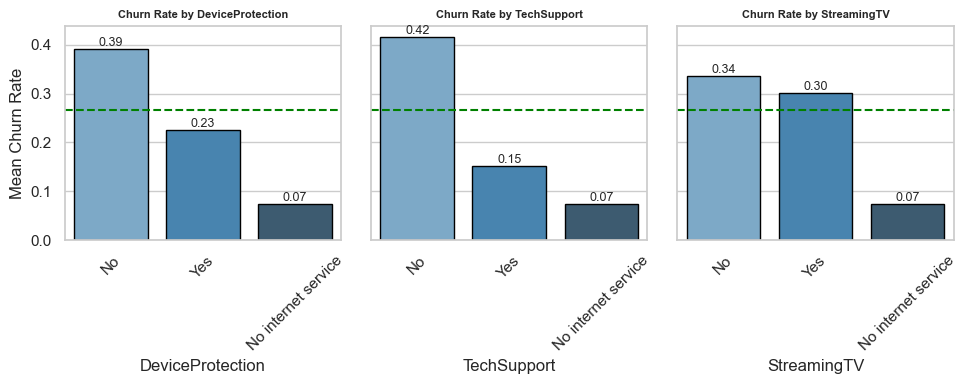

C:\Users\joseph\AppData\Local\Temp\ipykernel_8240\1798210915.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\joseph\AppData\Local\Temp\ipykernel_8240\1798210915.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\joseph\AppData\Local\Temp\ipykernel_8240\1798210915.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


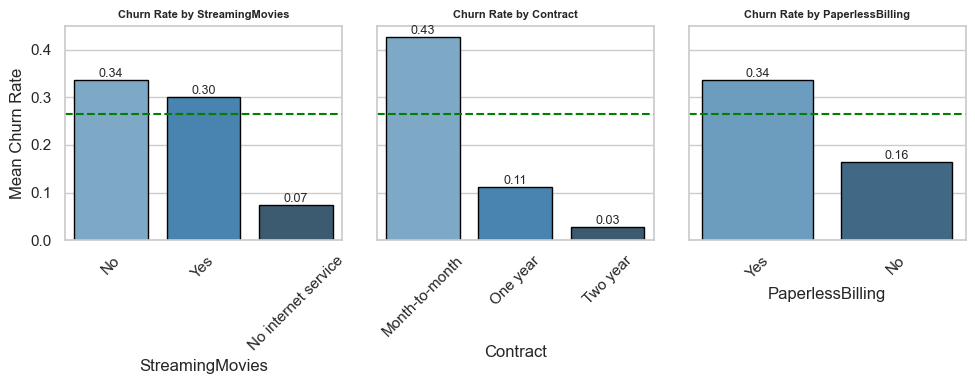

C:\Users\joseph\AppData\Local\Temp\ipykernel_8240\1798210915.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


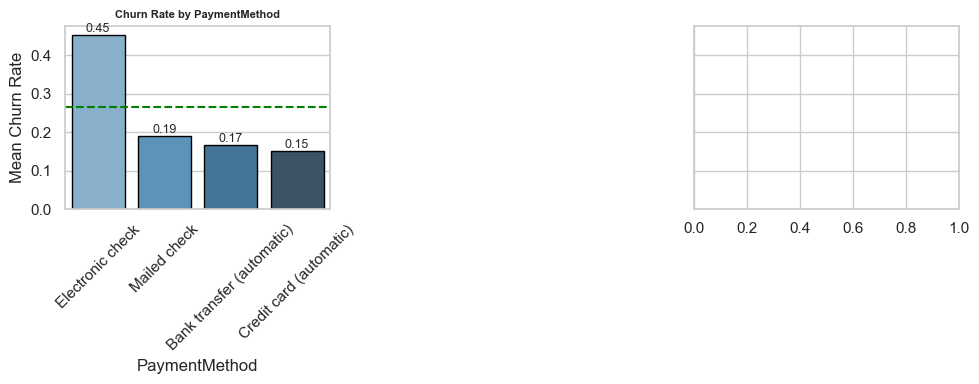

In [27]:
sns.set(style="whitegrid")

if len(categorical) % 3 != 0:
    categorical.append(None)

for i in range(0, len(categorical), 3):
    features_pair = categorical[i:i+3]
    
    fig, axes = plt.subplots(1, 3, figsize=(10, 4), sharey=True)
    
    for j, feature in enumerate(features_pair):
        ax = axes[j]
        if feature is None:
            ax.axis('off') 
            continue

        df_group = df.groupby(by=feature).Churn.agg(['mean', 'count']).reset_index()
        df_group = df_group.sort_values('mean', ascending=False)
        
        sns.barplot(
            x=feature,
            y='mean',
            data=df_group,
            palette='Blues_d',
            edgecolor='black',
            ax=ax
        )

        for p in ax.patches:
            ax.annotate(f'{p.get_height():.2f}',
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='bottom',
                        fontsize=9)

        ax.axhline(global_mean, linewidth=1.5, color='green', linestyle='--')
        ax.text(-0.4, global_mean + 0.01, ' ', color='green')

        ax.set_title(f'Churn Rate by {feature}', fontsize=8, weight='bold')
        ax.set_xlabel(feature)
        ax.set_ylabel('Mean Churn Rate' if j == 0 else '')
        ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()


> ### Some Insights
* `For gender, there is not much difference between females and males.`

* Senior citizens tend to churn more than nonseniors.

* `People with a partner churn less than people with no partner.`

* People who use phone service are not at risk of churning. People who don’t use phone service are even less likely to churn.

* `Clients with no tech support tend to churn more than those who do.`

* People with monthly contracts cancel the contract a lot more often than others, and people with two-year contacts churn very rarely.

In [32]:
from sklearn.metrics import mutual_info_score

def calculate_mi(series):
    return mutual_info_score(series, df.Churn)

df_mi = df[categorical].apply(calculate_mi)
df_mi = df_mi.sort_values(ascending=False).to_frame(name='MI')
display(df_mi.head())
display(df_mi.tail())

,MI
Contract,0.098453
OnlineSecurity,0.064677
TechSupport,0.063021
InternetService,0.055574
OnlineBackup,0.046792


,MI
Partner,0.011454
SeniorCitizen,0.010577
MultipleLines,0.000801
PhoneService,0.000072
gender,0.000037


* Higher values of mutual information mean a higher degree of dependence: if the mutual information between a categorical variable and the target is high, this categorical variable will be quite useful for predicting the target. 

* On the other hand, if the mutual information is low, the categorical variable and the target are independent, and thus the variable will not be useful for predicting the target.

In [33]:
df[numerical].corrwith(df.Churn)

tenure           -0.352229
MonthlyCharges    0.193356
TotalCharges     -0.199037
dtype: float64

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_churn_by_range(df, column, ranges, labels, title):
    churn_rates = []
    for r in ranges:
        if r[0] is None:
            data = df[df[column] <= r[1]]
        elif r[1] is None:
            data = df[df[column] >= r[0]]
        else:
            data = df[(df[column] >= r[0]) & (df[column] <= r[1])]
        churn_rates.append(data['Churn'].mean())

    sns.barplot(x=labels, y=churn_rates, palette='Blues_d')
    plt.title(title)
    plt.xlabel(column)
    plt.ylabel('Churn Rate')
    plt.show()


C:\Users\joseph\AppData\Local\Temp\ipykernel_8240\2921272064.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=churn_rates, palette='Blues_d')


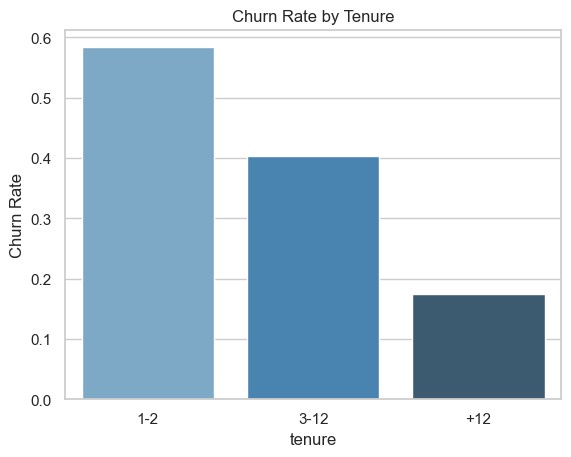

C:\Users\joseph\AppData\Local\Temp\ipykernel_8240\2921272064.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=churn_rates, palette='Blues_d')


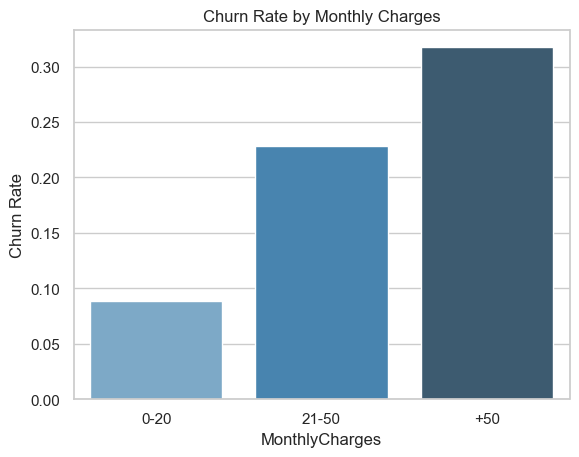

C:\Users\joseph\AppData\Local\Temp\ipykernel_8240\2921272064.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=churn_rates, palette='Blues_d')


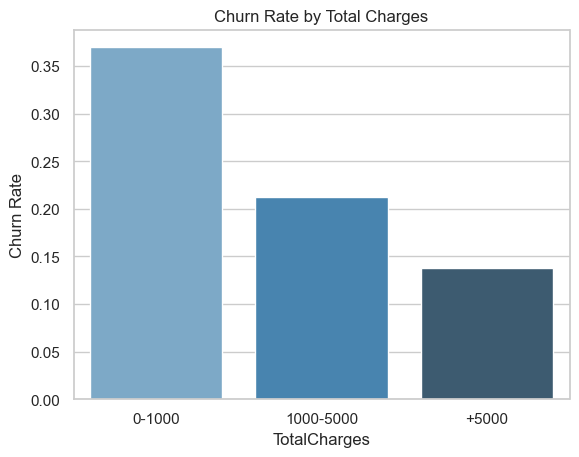

In [35]:
plot_churn_by_range(
    df,
    column='tenure',
    ranges=[(None, 2), (3, 12), (12, None)],
    labels=['1-2', '3-12', '+12'],
    title='Churn Rate by Tenure'
)

plot_churn_by_range(
    df,
    column='MonthlyCharges',
    ranges=[(None, 20), (21, 50), (50, None)],
    labels=['0-20', '21-50', '+50'],
    title='Churn Rate by Monthly Charges'
)

plot_churn_by_range(
    df,
    column='TotalCharges',
    ranges=[(None, 1000), (1001, 5000), (5000, None)],
    labels=['0-1000', '1000-5000', '+5000'],
    title='Churn Rate by Total Charges'
)



**Tenure**
* > The correlation between `tenure` and `churn` is –0.35: it has a negative sign, so the longer customers stay, the less often they tend to churn

**Monthly Charges**
* > `monthlycharges` has a positive coefficient of 0.19, which means that customers who pay more tend to leave more often.

**Total Charges**
* > `totalcharges` has a negative correlation, which makes sense: the longer people stay with the company, the more they have paid in total, so it’s less likely that they will leave.

# Data Splitting 

In [36]:
from sklearn.model_selection import train_test_split

df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_valid = train_test_split(df_full_train, test_size=0.2, random_state=1)
print("Training Data Size: ", df_train.shape)
print("Validation Data Size: ", df_valid.shape)
print("Testing Data Size: ", df_test.shape)

Training Data Size:  (4507, 20)
Validation Data Size:  (1127, 20)
Testing Data Size:  (1409, 20)


In [37]:
y_train = df_train['Churn']
y_valid = df_valid['Churn']
y_test = df_test['Churn']

# Preprocessing

In [38]:
df[numerical].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2281.916928
std,24.559481,30.090047,2265.270398
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,402.225000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


* There is a GAP between the mean of numerical values, so we need to scale it 

*  Handling Categorical Variables `one-hot encoding`

* Scaling Numerical Variables `Standard Scaler`

In [39]:
def preprocess(df_train, df_valid, df_test, num, cat):
    ohe = OneHotEncoder(drop='first')
    scaler = StandardScaler()

    transformer = make_column_transformer((scaler, num),
                                           (ohe, cat),
                                          remainder='passthrough',verbose_feature_names_out=False)
    X_train = transformer.fit_transform(df_train[cat+num])
    X_valid = transformer.transform(df_valid[cat+num])
    X_test = transformer.transform(df_test[cat+num])
    columns=transformer.get_feature_names_out()
   
    return X_train , X_valid, X_test, columns

In [40]:
X_train , X_valid, X_test, columns = preprocess(df_train, df_valid, df_test, numerical, categorical)

In [41]:
X_train.shape

(4507, 30)

In [42]:
len(y_test)

1409

# Modelling
* We will use logistic regression as a classification model

In [43]:
from sklearn.linear_model import LogisticRegression
model_1 = LogisticRegression( random_state=1)
model_1.fit(X_train, y_train)

LogisticRegression(random_state=1)

In [44]:
len(columns)

30

In [45]:
len(model_1.coef_[0])

30

In [46]:
y_val_pred = model_1.predict_proba(X_valid)
y_val_pred

array([[0.99297025, 0.00702975],
       [0.80075931, 0.19924069],
       [0.7887775 , 0.2112225 ],
       ...,
       [0.96094628, 0.03905372],
       [0.42145266, 0.57854734],
       [0.70427791, 0.29572209]], shape=(1127, 2))

In [47]:
y_test_pred = model_1.predict_proba(X_test)
y_test_pred

array([[0.9435023 , 0.0564977 ],
       [0.91604743, 0.08395257],
       [0.66814302, 0.33185698],
       ...,
       [0.99477725, 0.00522275],
       [0.80658457, 0.19341543],
       [0.39172114, 0.60827886]], shape=(1409, 2))

In [48]:
y_test_pred[:,1]

array([0.0564977 , 0.08395257, 0.33185698, ..., 0.00522275, 0.19341543,
       0.60827886], shape=(1409,))

In [49]:
print('LogisticRegression Training Accuracy: ', round(model_1.score(X_train, y_train), 2))
print('LogisticRegression Validation Accuracy: ', round(model_1.score(X_valid, y_valid), 2))
print('LogisticRegression Testing Accuracy: ', round(model_1.score(X_test, y_test), 2))

LogisticRegression Training Accuracy:  0.81
LogisticRegression Validation Accuracy:  0.8
LogisticRegression Testing Accuracy:  0.81


In [50]:
from sklearn.metrics import classification_report

y_pred = model_1.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.88      0.87      1061
           1       0.62      0.58      0.60       348

    accuracy                           0.81      1409
   macro avg       0.74      0.73      0.74      1409
weighted avg       0.81      0.81      0.81      1409



* ### Repeat Training and Evaluation After Applying EDA 

> First we need to handle imbalanced `Churn` Data 

* Apply oversampling to generate a synthetic composition to balance the distribution of a dataset.

In [62]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)


In [63]:
len(X_train_sm)

6598

C:\Users\joseph\AppData\Local\Temp\ipykernel_8240\4018069547.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_sm,palette='Blues_d')


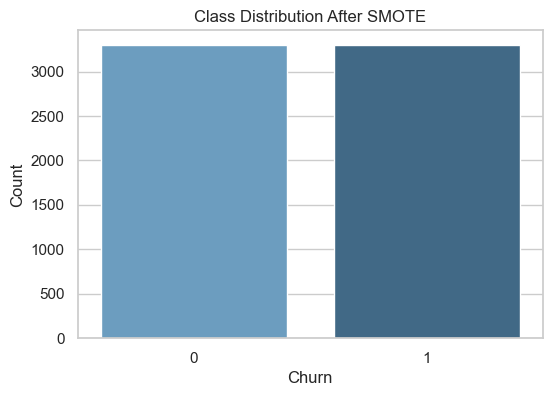

In [64]:
plt.figure(figsize=(6,4),)
sns.countplot(x=y_train_sm,palette='Blues_d')
plt.title("Class Distribution After SMOTE")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()


In [73]:
from sklearn.svm import SVC

model_2 = SVC(probability=True)
model_2.fit(X_train_sm, y_train_sm)

SVC(probability=True)

In [75]:
print('Training Accuracy: ', round(model_2.score(X_train_sm, y_train_sm), 2))
print('Validation Accuracy: ', round(model_2.score(X_valid, y_valid), 2))
print('Testing Accuracy: ', round(model_2.score(X_test, y_test), 2))

Training Accuracy:  0.77
Validation Accuracy:  0.76
Testing Accuracy:  0.77


* Apply Keep the most important categorical fetcher based on high mutual information (MI) Score 

In [76]:
important_cat = df_mi.head().index.to_list()
important_cat

['Contract',
 'OnlineSecurity',
 'TechSupport',
 'InternetService',
 'OnlineBackup']

In [109]:
X_train, X_valid, X_test, columns = preprocess(df_train, df_valid, df_test, numerical, important_cat)

model_3 = SVC(probability=True)
model_3.fit(X_train_sm, y_train_sm)

print('LogisticRegression Training Accuracy: ', round(model_3.score(X_train_sm, y_train_sm), 2))
print('LogisticRegression Validation Accuracy: ', round(model_3.score(X_valid, y_valid), 2))
print('LogisticRegression Testing Accuracy: ', round(model_3.score(X_test, y_test), 2))

LogisticRegression Training Accuracy:  0.77
LogisticRegression Validation Accuracy:  0.76
LogisticRegression Testing Accuracy:  0.77


In [110]:
from sklearn.metrics import classification_report

y_pred = model_3.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.76      0.83      1061
           1       0.52      0.80      0.63       348

    accuracy                           0.77      1409
   macro avg       0.72      0.78      0.73      1409
weighted avg       0.82      0.77      0.78      1409

